# Object Detection

## What is Object Detection?
Object detection simultaneously **localizes** (bounding box) and **classifies** (label) multiple objects in an image. Output: list of `(class, confidence, x1, y1, x2, y2)`.

---

## Key Metrics

**Intersection over Union (IoU)**:
$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}} = \frac{|A \cap B|}{|A \cup B|}$$

**Precision & Recall** at threshold $t$:
$$P = \frac{TP}{TP + FP}, \quad R = \frac{TP}{TP + FN}$$

**Average Precision (AP)**: area under the Precision-Recall curve
$$AP = \int_0^1 p(r)\, dr \approx \sum_{k=1}^N P(k) \cdot \Delta R(k)$$

**mAP** (mean AP across all classes):
$$mAP = \frac{1}{|C|} \sum_{c \in C} AP_c$$

COCO uses mAP averaged over IoU thresholds 0.50:0.05:0.95.

---

## Two-Stage Detectors

### R-CNN Family

| Model | Speed | Key Innovation |
|-------|-------|----------------|
| R-CNN (2014) | Slow (47s/img) | CNN features on selective search regions |
| Fast R-CNN (2015) | 2s/img | RoI Pooling on shared conv feature map |
| Faster R-CNN (2016) | 0.2s/img | RPN replaces selective search |

**RPN (Region Proposal Network)** scores $2k$ objectness and regresses $4k$ box offsets for $k$ anchors per location:
$$t_x = (x - x_a)/w_a, \quad t_y = (y - y_a)/h_a$$
$$t_w = \log(w/w_a), \quad t_h = \log(h/h_a)$$

**RoI Align** (used in Mask R-CNN) fixes the quantization error of RoI Pooling using bilinear interpolation.

---

## One-Stage Detectors

### YOLO Family

| Version | Year | mAP (COCO) | FPS | Key Change |
|---------|------|------------|-----|------------|
| YOLOv1 | 2016 | | 45 | Grid-based, single pass |
| YOLOv2 | 2017 | | 67 | Anchor boxes, batch norm |
| YOLOv3 | 2018 | 33.0 | 30 | Multi-scale, DarkNet-53 |
| YOLOv4 | 2020 | 43.5 | 65 | CSPNet, PANet, SAM |
| YOLOv5 | 2020 | 50.7 | 140 | PyTorch, auto-anchor |
| YOLOv6 | 2022 | 52.8 | | EfficientRep |
| YOLOv7 | 2022 | 56.8 | 161 | E-ELAN, auxiliary heads |
| YOLOv8 | 2023 | 53.9 | 280 | Anchor-free, Ultralytics |
| YOLOv9 | 2024 | 55.6 | | GELAN, PGI |
| YOLOv10 | 2024 | 54.4 | 500+ | NMS-free, dual head |
| YOLOv11 | 2024 | 54.7 | | C3k2 block, improved arch |

**YOLO loss** (v1 style):
$$L = \lambda_{coord}\sum_{i}\sum_{j} \mathbf{1}_{ij}^{obj}[(x_i-\hat{x}_i)^2+(y_i-\hat{y}_i)^2]$$
$$+ \lambda_{coord}\sum_{i}\sum_{j} \mathbf{1}_{ij}^{obj}[(\sqrt{w_i}-\sqrt{\hat{w}_i})^2+(\sqrt{h_i}-\sqrt{\hat{h}_i})^2]$$
$$+ \sum_{i}\sum_{j} \mathbf{1}_{ij}^{obj}(C_i - \hat{C}_i)^2 + \lambda_{noobj}\sum_{i}\sum_{j}\mathbf{1}_{ij}^{noobj}(C_i-\hat{C}_i)^2$$
$$+ \sum_{i}\mathbf{1}_i^{obj}\sum_{c\in classes}(p_i(c)-\hat{p}_i(c))^2$$

### RetinaNet Focal Loss

Standard cross-entropy is dominated by easy negatives. Focal loss down-weights easy examples:
$$FL(p_t) = -\alpha_t(1-p_t)^\gamma \log(p_t)$$

where $\gamma=2$ (focusing parameter) reduces loss from well-classified examples by factor $(1-p_t)^2$.

### SSD (Single Shot MultiBox Detector)
Uses multiple feature maps at different scales (38×38, 19×19, 10×10, 5×5, 3×3, 1×1) to detect objects at different sizes.

---

## DETR Transformer-based Detection

DETR frames detection as a set prediction problem, using Hungarian matching:
$$\hat{\sigma} = \arg\min_{\sigma \in S_N} \sum_{i=1}^N \mathcal{L}_{match}(y_i, \hat{y}_{\sigma(i)})$$

Eliminates NMS entirely. Architecture: CNN backbone → Transformer encoder-decoder → FFN heads.

---

## Non-Maximum Suppression (NMS)

1. Sort boxes by confidence
2. Pick highest-confidence box
3. Remove all boxes with IoU > threshold with picked box
4. Repeat

**Soft-NMS** decays confidence instead of removing:
$$s_i = s_i \cdot e^{-\frac{IoU(\mathcal{M}, b_i)^2}{\sigma}}$$


IoU: 0.1429


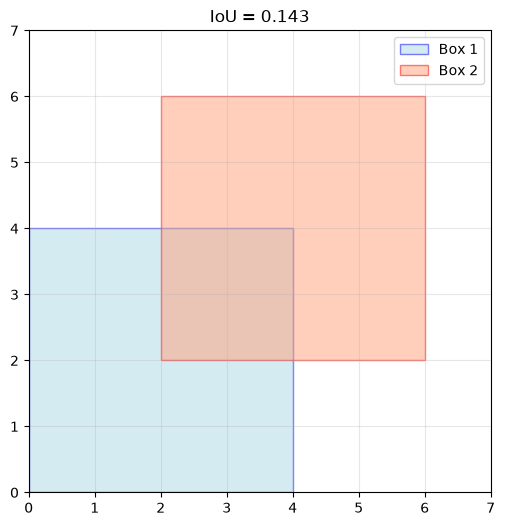

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ============================================================
# IoU Calculation
# ============================================================

def compute_iou(box1, box2):
    """
    Compute IoU between two boxes.
    Boxes in format [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection
    return intersection / (union + 1e-8)

# Test
b1 = [0, 0, 4, 4]
b2 = [2, 2, 6, 6]
print(f'IoU: {compute_iou(b1, b2):.4f}')  # overlap 2x2=4, union=4*4+4*4-4=28, iou=4/28

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 7); ax.set_ylim(0, 7); ax.set_aspect('equal')
rect1 = patches.Rectangle((b1[0], b1[1]), b1[2]-b1[0], b1[3]-b1[1],
                            edgecolor='blue', facecolor='lightblue', alpha=0.5, label='Box 1')
rect2 = patches.Rectangle((b2[0], b2[1]), b2[2]-b2[0], b2[3]-b2[1],
                            edgecolor='red', facecolor='lightsalmon', alpha=0.5, label='Box 2')
ax.add_patch(rect1); ax.add_patch(rect2)
ax.set_title(f'IoU = {compute_iou(b1, b2):.3f}')
ax.legend(); ax.grid(True, alpha=0.3); plt.show()

In [2]:
# ============================================================
# NMS Implementation from Scratch
# ============================================================

def nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression.
    boxes: (N, 4) array [x1, y1, x2, y2]
    scores: (N,) confidence scores
    Returns indices of kept boxes.
    """
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]  # Sort by score descending

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)

        # Compute IoU with remaining boxes
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]

    return keep


# Soft-NMS
def soft_nms(boxes, scores, sigma=0.5, score_threshold=0.3):
    """Soft-NMS: decay scores instead of removing boxes."""
    N = len(boxes)
    scores = scores.copy()
    keep = []

    for i in range(N):
        # Find max score
        max_idx = np.argmax(scores)
        if scores[max_idx] < score_threshold:
            break
        keep.append(max_idx)

        for j in range(N):
            if j == max_idx: continue
            iou = compute_iou(boxes[max_idx], boxes[j])
            scores[j] *= np.exp(-iou**2 / sigma)  # Gaussian decay

        scores[max_idx] = -1  # Remove from future consideration

    return keep


# Test NMS
boxes  = np.array([[10,10,50,50],[12,12,52,52],[60,60,100,100],[62,62,102,102]], dtype=float)
scores = np.array([0.9, 0.75, 0.8, 0.6])

kept = nms(boxes, scores, iou_threshold=0.5)
print('NMS kept boxes:', kept)
print('Kept scores:', scores[kept])

NMS kept boxes: [np.int64(0), np.int64(2)]
Kept scores: [0.9 0.8]


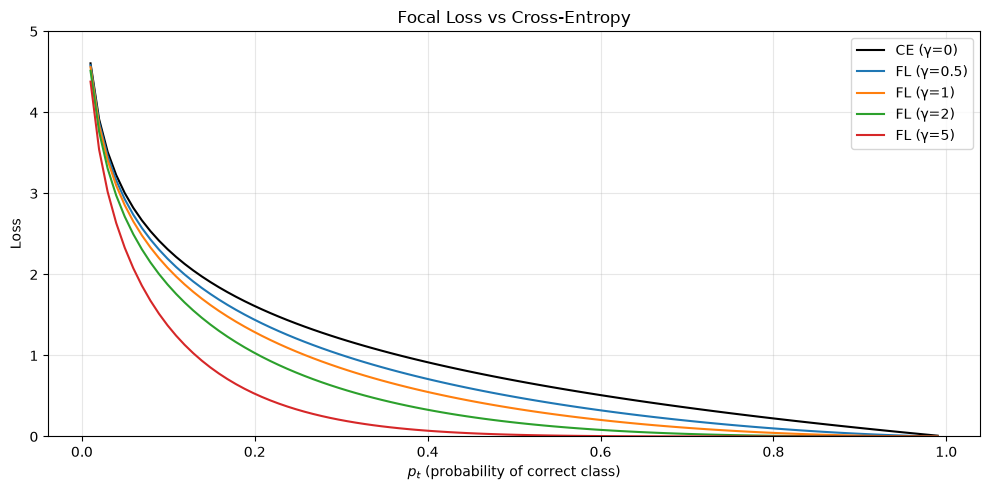

Notice how focal loss suppresses easy examples (high p_t).


In [3]:
# ============================================================
# Focal Loss Implementation
# ============================================================
import torch
import torch.nn.functional as F

def focal_loss(inputs, targets, alpha=0.25, gamma=2.0, reduction='mean'):
    """
    Sigmoid focal loss for dense object detection.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    BCE = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
    p   = torch.sigmoid(inputs)
    p_t = p * targets + (1 - p) * (1 - targets)
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
    focal_weight = alpha_t * (1 - p_t) ** gamma
    loss = focal_weight * BCE
    return loss.mean() if reduction == 'mean' else loss.sum()


# Visualize: focal loss vs cross-entropy
p_t = np.linspace(0.01, 0.99, 100)
ce  = -np.log(p_t)

plt.figure(figsize=(10, 5))
plt.plot(p_t, ce, 'k-', label='CE (γ=0)')
for gamma in [0.5, 1, 2, 5]:
    fl = -(1 - p_t)**gamma * np.log(p_t)
    plt.plot(p_t, fl, label=f'FL (γ={gamma})')
plt.xlabel('$p_t$ (probability of correct class)')
plt.ylabel('Loss')
plt.title('Focal Loss vs Cross-Entropy')
plt.legend(); plt.ylim(0, 5); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('Notice how focal loss suppresses easy examples (high p_t).')

In [4]:
# ============================================================
# YOLOv8 with Ultralytics Production Ready
# ============================================================
# pip install ultralytics

print('YOLOv8 / YOLOv11 with Ultralytics:')
print('=' * 50)
yolo_code = '''
from ultralytics import YOLO

# ---- Inference ----
model = YOLO('yolov8n.pt')          # nano (fastest)
# model = YOLO('yolov8s.pt')        # small
# model = YOLO('yolov8m.pt')        # medium
# model = YOLO('yolov8l.pt')        # large
# model = YOLO('yolov8x.pt')        # extra-large (best accuracy)

results = model('image.jpg')        # Inference on single image
results = model('video.mp4')        # On video
results = model(source=0)           # Webcam stream

for r in results:
    boxes = r.boxes               # Bounding boxes
    masks = r.masks               # Segmentation masks (if seg model)
    keypoints = r.keypoints       # Pose keypoints (if pose model)

    for box in boxes:
        print(box.xyxy, box.conf, box.cls)

# ---- Training on custom dataset ----
model = YOLO('yolov8n.pt')
results = model.train(
    data='coco128.yaml',   # Dataset config
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,              # GPU id
    optimizer='AdamW',
    lr0=0.001,
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    degrees=10.0,
    fliplr=0.5,
)

# ---- Evaluation ----
metrics = model.val()      # Evaluate on val set
print(metrics.box.mAP50)  # mAP@0.5
print(metrics.box.mAP50_95)  # mAP@0.5:0.95

# ---- Export ----
model.export(format='onnx')          # ONNX
model.export(format='tensorrt')      # TensorRT
model.export(format='coreml')        # Apple CoreML
'''
print(yolo_code)

YOLOv8 / YOLOv11 with Ultralytics:

from ultralytics import YOLO

# ---- Inference ----
model = YOLO('yolov8n.pt')          # nano (fastest)
# model = YOLO('yolov8s.pt')        # small
# model = YOLO('yolov8m.pt')        # medium
# model = YOLO('yolov8l.pt')        # large
# model = YOLO('yolov8x.pt')        # extra-large (best accuracy)

results = model('image.jpg')        # Inference on single image
results = model('video.mp4')        # On video
results = model(source=0)           # Webcam stream

for r in results:
    boxes = r.boxes               # Bounding boxes
    masks = r.masks               # Segmentation masks (if seg model)
    keypoints = r.keypoints       # Pose keypoints (if pose model)

    for box in boxes:
        print(box.xyxy, box.conf, box.cls)

# ---- Training on custom dataset ----
model = YOLO('yolov8n.pt')
results = model.train(
    data='coco128.yaml',   # Dataset config
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,              # GPU id
    opti

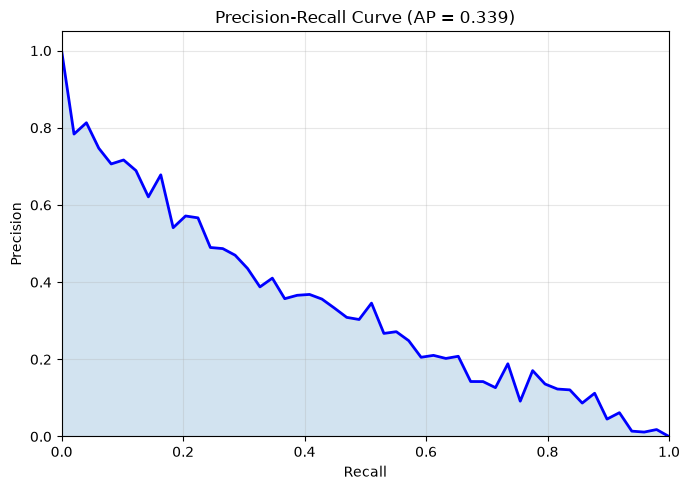

In [5]:
# ============================================================
# mAP Calculation
# ============================================================

def compute_ap(recall, precision):
    """Compute Average Precision from recall-precision curve (VOC 2010+)."""
    # Append sentinel values
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))

    # Compute envelope (monotonically decreasing)
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Integrate: sum over points where recall changes
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])
    return ap


# Simulate PR curve
recall    = np.linspace(0, 1, 50)
precision = 1 - recall**0.5 + np.random.normal(0, 0.03, 50)
precision = np.clip(precision, 0, 1)
ap = compute_ap(recall, precision)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, 'b-', linewidth=2)
plt.fill_between(recall, precision, alpha=0.2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP = {ap:.3f})')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Additional Learning Resources

### Foundational Papers
- [R-CNN](https://arxiv.org/abs/1311.2524) Rich feature hierarchies for accurate object detection (Girshick 2014)
- [Fast R-CNN](https://arxiv.org/abs/1504.08083) Girshick 2015
- [Faster R-CNN](https://arxiv.org/abs/1506.01497) Ren et al. 2015
- [YOLO](https://arxiv.org/abs/1506.02640) You Only Look Once (Redmon 2016)
- [SSD](https://arxiv.org/abs/1512.02325) Single Shot MultiBox Detector (Liu 2016)
- [RetinaNet & Focal Loss](https://arxiv.org/abs/1708.02002) Lin et al. 2017
- [DETR](https://arxiv.org/abs/2005.12872) End-to-End Object Detection with Transformers
- [YOLOv4](https://arxiv.org/abs/2004.10934) Optimal Speed and Accuracy
- [YOLOv7](https://arxiv.org/abs/2207.02696) Trainable bag-of-freebies
- [YOLOv9](https://arxiv.org/abs/2402.13616) Learning What You Want to Learn
- [YOLOv10](https://arxiv.org/abs/2405.14458) Real-Time End-to-End Object Detection

### Libraries & Tools
- [Ultralytics YOLOv8/v11](https://docs.ultralytics.com/) Best production YOLO implementation
- [MMDetection](https://mmdetection.readthedocs.io/) OpenMMLab detection toolbox
- [Detectron2](https://detectron2.readthedocs.io/) Facebook AI's detection framework
- [Roboflow](https://roboflow.com/) Dataset management and annotation for detection
- [torchvision detection](https://pytorch.org/vision/stable/models.html#object-detection) Faster R-CNN, RetinaNet

### Courses
- [CS231n Detection, Segmentation](http://cs231n.stanford.edu/slides/2023/lecture_11.pdf)
- [Ultralytics YOLO Docs](https://docs.ultralytics.com/tasks/detect/)
- [Papers with Code Object Detection COCO](https://paperswithcode.com/sota/object-detection-on-coco)
